In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('ABC Company.xlsx - Sheet1.csv')

In [3]:
data.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0


In [4]:
data.tail()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
453,Shelvin Mack,Utah Jazz,8,PG,26,06-Mar,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,06-Jan,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,07-Mar,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,7-0,231,Kansas,947276.0
457,Priyanka,Utah Jazz,34,C,25,07-Mar,231,Kansas,947276.0


In [5]:
data.isnull().sum()

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64

In [ ]:
# Step 1 — Preprocessing
import numpy as np

# use random seed so results are reproducible
np.random.seed(42)

# replace height column with random integers from 150–180
data['Height'] = np.random.randint(150, 181, size=len(data))

# check a few rows to confirm
data.head()


In [6]:
np.random.seed(42)
data['Height'] = np.random.randint(150, 180, size=len(data))
data.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,156,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,169,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,178,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,164,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,160,231,NaN,5000000.0


In [7]:
# Step 2 — Employee Distribution Across Teams

# count how many employees are in each team
team_distribution = data['Team'].value_counts().reset_index()

# renaming the columns to make them easier to read
team_distribution.columns = ['Team', 'Count']

# calculate the percentage of total employees for each team
team_distribution['Percentage'] = (team_distribution['Count'] / len(data) * 100).round(2)

# display
team_distribution


,Team,Count,Percentage
0,New Orleans Pelicans,19,4.15
1,Memphis Grizzlies,18,3.93
2,Utah Jazz,16,3.49
3,New York Knicks,16,3.49
4,Milwaukee Bucks,16,3.49
5,Brooklyn Nets,15,3.28
6,Portland Trail Blazers,15,3.28
7,Oklahoma City Thunder,15,3.28
8,Denver Nuggets,15,3.28
9,Washington Wizards,15,3.28


In [9]:
data['Team'].unique()


array(['Boston Celtics', 'Brooklyn Nets', 'New York Knicks',
       'Philadelphia 76ers', 'Toronto Raptors', 'Golden State Warriors',
       'Los Angeles Clippers', 'Los Angeles Lakers', 'Phoenix Suns',
       'Sacramento Kings', 'Chicago Bulls', 'Cleveland Cavaliers',
       'Detroit Pistons', 'Indiana Pacers', 'Milwaukee Bucks',
       'Dallas Mavericks', 'Houston Rockets', 'Memphis Grizzlies',
       'New Orleans Pelicans', 'San Antonio Spurs', 'Atlanta Hawks',
       'Charlotte Hornets', 'Miami Heat', 'Orlando Magic',
       'Washington Wizards', 'Denver Nuggets', 'Minnesota Timberwolves',
       'Oklahoma City Thunder', 'Portland Trail Blazers', 'Utah Jazz'],
      dtype=object)

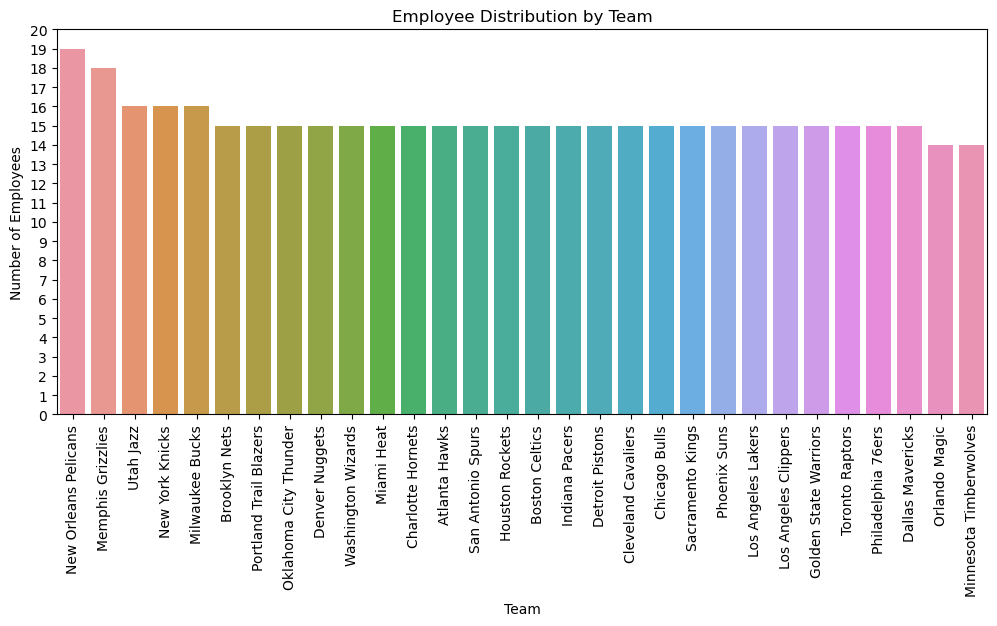

In [10]:
plt.figure(figsize=(12,5))
sns.barplot(x='Team', y='Count', data=team_distribution)
plt.xticks(rotation=90)
plt.title('Employee Distribution by Team')
plt.xlabel('Team')
plt.ylabel('Number of Employees')

# Force y-axis to show only whole numbers
plt.yticks(range(0, int(team_distribution['Count'].max()) + 2))
plt.show()


In [11]:
# Step 3 — Employees by Position

# Count how many employees (players) there are in each position
position_distribution = data['Position'].value_counts().reset_index()

# Renaming columns
position_distribution.columns = ['Position', 'Count']

# Calculate the percentage each position represents
position_distribution['Percentage'] = (position_distribution['Count'] / len(data) * 100).round(2)

# display
position_distribution


,Position,Count,Percentage
0,SG,102,22.27
1,PF,100,21.83
2,PG,92,20.09
3,SF,85,18.56
4,C,79,17.25


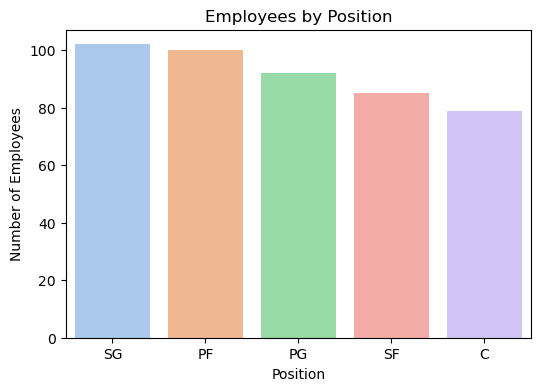

In [12]:
plt.figure(figsize=(6,4))
sns.barplot(x='Position', y='Count', data=position_distribution, palette='pastel')
plt.title('Employees by Position')
plt.xlabel('Position')
plt.ylabel('Number of Employees')
plt.show()


In [13]:
# Step 4 — Predominant Age Group

# Define age ranges (bins) and their labels
bins = [20, 25, 30, 35, 40, 45]  
labels = ['20-24', '25-29', '30-34', '35-39', '40-44']

# Create a new column called AgeGroup
data['AgeGroup'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)

# Count how many employees fall into each group
age_group_distribution = data['AgeGroup'].value_counts().reset_index()
age_group_distribution.columns = ['AgeGroup', 'Count']

# Sort in ascending order of age
age_group_distribution = age_group_distribution.sort_values('AgeGroup')

# Display the result
age_group_distribution


,AgeGroup,Count
1,20-24,152
0,25-29,182
2,30-34,90
3,35-39,29
4,40-44,3


C:\Users\HP\anaconda3\ANaconda\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


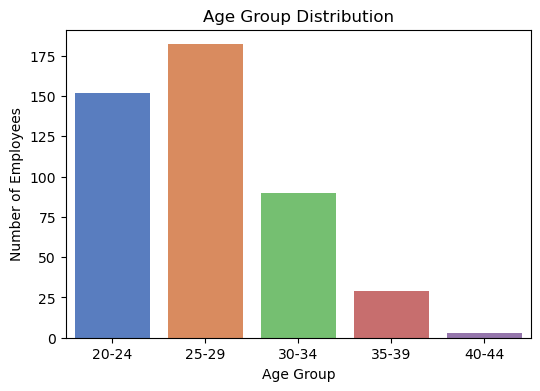

In [14]:
plt.figure(figsize=(6,4))
sns.barplot(x='AgeGroup', y='Count', data=age_group_distribution, palette='muted')
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Employees')
plt.show()


In [15]:
# Step 5 — Team & Position with Highest Salary Expenditure

# Group the data by Team and Position, then sum up their salaries
salary_spend = data.groupby(['Team', 'Position'])['Salary'].sum().reset_index()

# Renaming the column 
salary_spend.columns = ['Team', 'Position', 'Total_Salary']

# Sorting to find the top salary combination
top_salary = salary_spend.sort_values('Total_Salary', ascending=False).head(1)

# Display the top result
top_salary


,Team,Position,Total_Salary
67,Los Angeles Lakers,SF,31866445.0


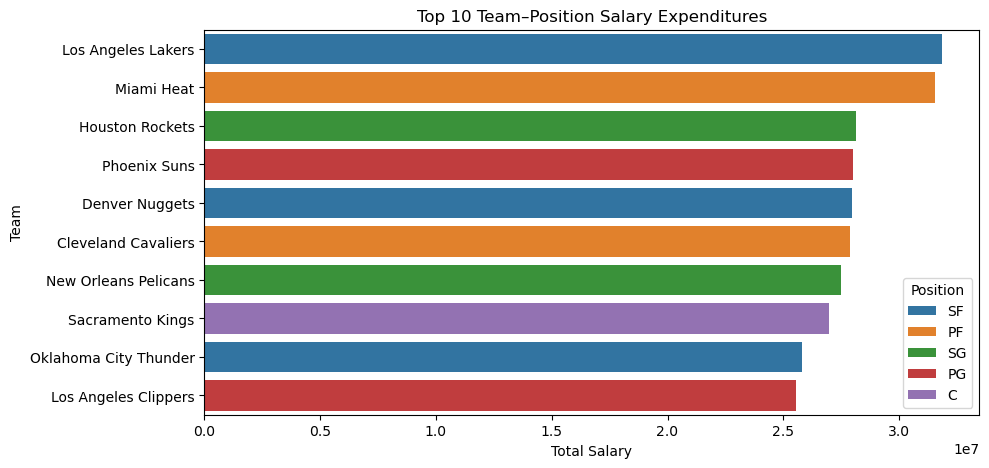

In [16]:
plt.figure(figsize=(10,5))
top10_salary = salary_spend.sort_values('Total_Salary', ascending=False).head(10)
sns.barplot(x='Total_Salary', y='Team', hue='Position', data=top10_salary, dodge=False)
plt.title('Top 10 Team–Position Salary Expenditures')
plt.xlabel('Total Salary')
plt.ylabel('Team')
plt.legend(title='Position')
plt.show()


Correlation between Age and Salary: 0.21


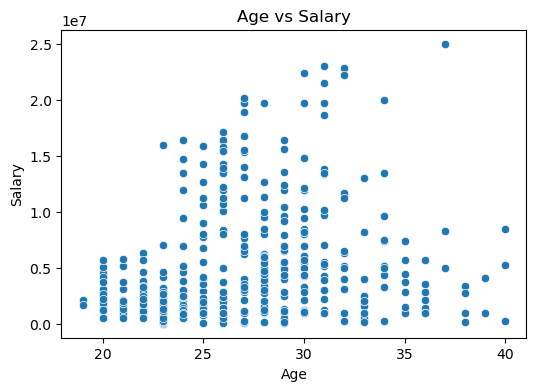

In [17]:
# Step 6 — Correlation Between Age and Salary

# Calculate the correlation between age and salary
correlation = data['Age'].corr(data['Salary'])
print("Correlation between Age and Salary:", round(correlation, 2))

#  a scatter plot to visualize the relationship
plt.figure(figsize=(6,4))
sns.scatterplot(x='Age', y='Salary', data=data)
plt.title('Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.show()


          Number       Age    Weight    Salary
Number  1.000000  0.027702  0.207459 -0.113883
Age     0.027702  1.000000  0.086806  0.214009
Weight  0.207459  0.086806  1.000000  0.137626
Salary -0.113883  0.214009  0.137626  1.000000


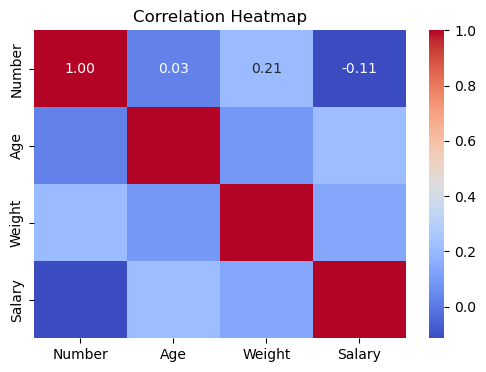

In [20]:
# Step 6 — Correlation Heatmap

# only the numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Display the correlation matrix
print(corr_matrix)

# Plot the heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()
